In [97]:
import numpy as np
import pandas as pd

In [100]:
data=pd.read_csv("../artifacts/sensor_data2.csv")
data.tail()

,Time(s),vibration_mm_s,temperature_C,current_A,label
2995,996,8.64,81.2,3.64,2
2996,997,9.22,80.5,3.66,2
2997,998,9.28,81.2,3.61,2
2998,999,8.16,81.1,3.73,2
2999,1000,7.33,77.9,3.60,2


In [101]:
data.shape

(3000, 5)

In [102]:
data['label'].value_counts()

label
0    1000
1    1000
2    1000
Name: count, dtype: int64

In [103]:
data['label'].value_counts()

label
0    1000
1    1000
2    1000
Name: count, dtype: int64

In [104]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Time(s)         3000 non-null   int64  
 1   vibration_mm_s  3000 non-null   float64
 2   temperature_C   3000 non-null   float64
 3   current_A       3000 non-null   float64
 4   label           3000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 117.3 KB


In [105]:
data.describe()


,Time(s),vibration_mm_s,temperature_C,current_A,label
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,500.500000,6.004890,63.996833,3.319810,1.000000
std,288.723115,2.599302,11.522116,0.328357,0.816633
min,1.000000,1.800000,40.000000,2.500000,0.000000
25%,250.750000,3.447500,53.275000,3.030000,0.000000
50%,500.500000,5.800000,64.900000,3.400000,1.000000
75%,750.250000,8.392500,74.600000,3.600000,2.000000
max,1000.000000,12.000000,85.000000,3.800000,2.000000


In [106]:
x=data.iloc[:,1:4]
x.head()



,vibration_mm_s,temperature_C,current_A
0,3.09,50.6,2.91
1,2.34,45.7,2.51
2,2.45,51.1,3.30
3,3.52,50.5,2.91
4,3.01,51.8,3.02


In [107]:
y = data.iloc[:,-1]
y.head()



0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64

In [108]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [109]:
x=scaler.fit_transform(x)
x[0:5]

array([[-1.12159941, -1.16289979, -1.24827183],
       [-1.41018648, -1.58823978, -2.46666262],
       [-1.36786037, -1.11949775, -0.0603408 ],
       [-0.95614282, -1.17158019, -1.24827183],
       [-1.15238203, -1.05873489, -0.91321436]])

In [110]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2)

In [111]:
x_train.shape


(2400, 3)

In [112]:
x_test.shape

(600, 3)

In [113]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=1)
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [114]:
pred=model.predict(x_test)
pred[0:5]


array([0, 2, 0, 2, 2])

In [115]:
y_test[0:5]


744     0
2214    2
771     0
2767    2
2773    2
Name: label, dtype: int64

In [116]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,pred)
accuracy

1.0

In [117]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,pred)
cm

array([[206,   0,   0],
       [  0, 201,   0],
       [  0,   0, 193]])

In [118]:
result = pd.DataFrame(data=[y_test.values,pred], index = ['y_test','pred'])
result.transpose()

,y_test,pred
0,0,0
1,2,2
2,0,0
3,2,2
4,2,2
...,...,...
595,2,2
596,0,0
597,0,0
598,1,1


In [119]:
correct_sum = [] 
for i in range(1,20):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    correct = np.sum(pred == y_test)
    correct_sum.append(correct) 

In [127]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

train_acc = []
test_acc = []

for i in range(1, 20):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train, y_train)
    
    # Training accuracy
    train_pred = model.predict(x_train)
    train_acc.append(accuracy_score(y_train, train_pred))
    
    # Testing accuracy
    test_pred = model.predict(x_test)
    test_acc.append(accuracy_score(y_test, test_pred))

print("Done! train_acc and test_acc are ready.")

Done! train_acc and test_acc are ready.


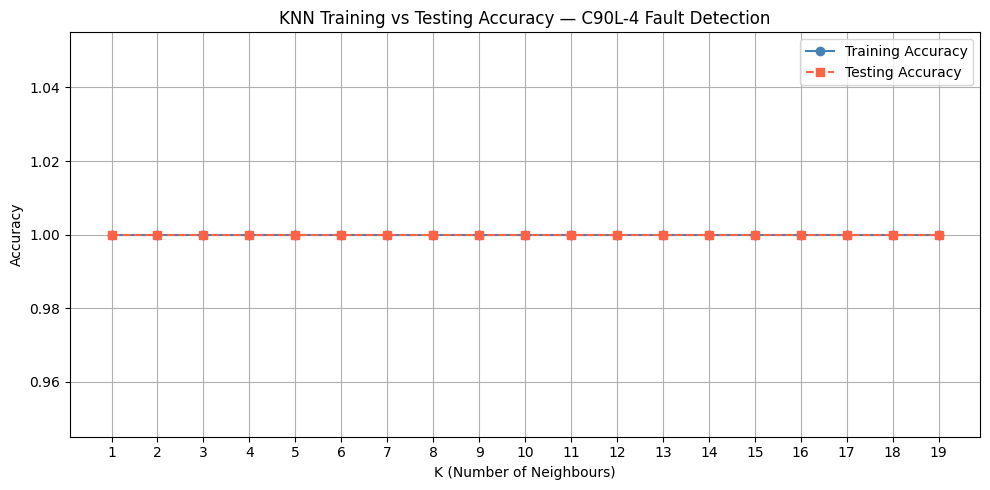

Best K: 1
Best Test Accuracy: 100.00%


In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, 20), train_acc, marker='o', label='Training Accuracy', color='steelblue')
plt.plot(range(1, 20), test_acc,  marker='s', label='Testing Accuracy',  color='tomato', linestyle='--')
plt.xlabel('K (Number of Neighbours)')
plt.ylabel('Accuracy')
plt.title('KNN Training vs Testing Accuracy — C90L-4 Fault Detection')
plt.xticks(range(1, 20))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best K: {test_acc.index(max(test_acc)) + 1}")
print(f"Best Test Accuracy: {max(test_acc)*100:.2f}%")

In [120]:
correct_sum

[np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600),
 np.int64(600)]

In [121]:
result = pd.DataFrame(data=correct_sum)
result.index = result.index+1
result.T

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,600,600,600,600,600,600,600,600,600,600,600,600,600,600,600,600,600,600,600


In [122]:
result = pd.DataFrame(data=[y_test.values,pred], index = ['y_test','pred'])
result.transpose()

,y_test,pred
0,0,0
1,2,2
2,0,0
3,2,2
4,2,2
...,...,...
595,2,2
596,0,0
597,0,0
598,1,1


In [123]:
train_pred = model.predict(x_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

Training Accuracy: 100.00%


In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, 20), train_acc, marker='o', label='Training Accuracy', color='steelblue')
plt.plot(range(1, 20), test_acc,  marker='s', label='Testing Accuracy',  color='tomato')
plt.xlabel('K (Number of Neighbours)')
plt.ylabel('Accuracy')
plt.title('KNN Training vs Testing Accuracy — C90L-4 Fault Detection')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'train_acc' is not defined

<Figure size 1000x500 with 0 Axes>

In [125]:
test_accuracy = accuracy_score(y_test, pred)
print(f"Testing Accuracy:  {test_accuracy * 100:.2f}%")

Testing Accuracy:  100.00%
